In [11]:
# Notebook for model comparison and evaluation
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [12]:
import pandas as pd
from src.data_ingestion import load_application_train, load_bureau, load_previous_application
from src.feature_engineering import engineer_features_pipeline, encode_categorical_features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

In [13]:
df_raw = load_application_train()
bureau_raw = load_bureau()
prev_app_raw = load_previous_application()

df = engineer_features_pipeline(df_raw, bureau_raw, prev_app_raw)

y = df['TARGET']
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
X_encoded = encode_categorical_features(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

Loaded application_train: 307511 rows, 122 columns
Loaded bureau: 1716428 rows, 17 columns
Loaded previous_application: 1670214 rows, 37 columns
(246008, 249) (61503, 249)


In [14]:
from src.feature_engineering import prepare_model_data

X_train_scaled, X_test_scaled, y_train, y_test, scaler = prepare_model_data(df)
print(X_train_scaled.shape, X_test_scaled.shape)

(246008, 249) (61503, 249)


In [15]:
# Training the Random Forest model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


In [16]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
# Evaluating the Random Forest model
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results:
Accuracy: 0.9181828528689657
Precision: 0.43920145190562615
Recall: 0.048741188318227595
F1 Score: 0.0877447425670776
ROC-AUC: 0.7400277089080567

Confusion Matrix:
[[56229   309]
 [ 4723   242]]


In [17]:
# Importing XGBoost and training the model
import xgboost
from xgboost import XGBClassifier
print(xgboost.__version__)

# scale_pos_weight = ratio of negative to positive class, XGBoost's balancing mechanism
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, y_train)

print("XGBoost trained successfully")

3.3.0
XGBoost trained successfully


In [18]:
# Evaluating the Random Forest model
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("XGBoost Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Results:
Accuracy: 0.7462400208119929
Precision: 0.18327380952380953
Recall: 0.6201409869083585
F1 Score: 0.2829313117390306
ROC-AUC: 0.7567695435846034

Confusion Matrix:
[[42817 13721]
 [ 1886  3079]]


In [26]:
# Re-training logistic regression model with scaled data
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [27]:
# Comparing logistic regression, random forest, and XGBoost models
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression': model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

cv_results = {}

for name, clf in models_cv.items():
    scores = cross_val_score(
        clf, X_train_scaled, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    cv_results[name] = scores
    print(f"{name}: mean ROC-AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression: mean ROC-AUC = 0.7507 (+/- 0.0029)
Random Forest: mean ROC-AUC = 0.7355 (+/- 0.0020)
XGBoost: mean ROC-AUC = 0.7480 (+/- 0.0013)


In [28]:
# Data visualization for model comparison
import matplotlib.pyplot as plt
import pandas as pd

comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Test ROC-AUC': [
        roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, xgb_model.predict_proba(X_test_scaled)[:, 1]),
    ],
    'CV Mean ROC-AUC': [cv_results[m].mean() for m in ['Logistic Regression', 'Random Forest', 'XGBoost']],
    'CV Std': [cv_results[m].std() for m in ['Logistic Regression', 'Random Forest', 'XGBoost']],
    'Recall': [
        recall_score(y_test, model.predict(X_test_scaled)),
        recall_score(y_test, rf_model.predict(X_test_scaled)),
        recall_score(y_test, xgb_model.predict(X_test_scaled)),
    ],
    'Precision': [
        precision_score(y_test, model.predict(X_test_scaled)),
        precision_score(y_test, rf_model.predict(X_test_scaled)),
        precision_score(y_test, xgb_model.predict(X_test_scaled)),
    ],
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.round(4))

# Save as CSV for README reference later
comparison_df.round(4).to_csv('../models/model_comparison.csv', index=False)

                 Model  Test ROC-AUC  CV Mean ROC-AUC  CV Std  Recall  \
0  Logistic Regression        0.7542           0.7507  0.0029  0.6824   
1        Random Forest        0.7400           0.7355  0.0020  0.0487   
2              XGBoost        0.7568           0.7480  0.0013  0.6201   

   Precision  
0     0.1641  
1     0.4392  
2     0.1833  


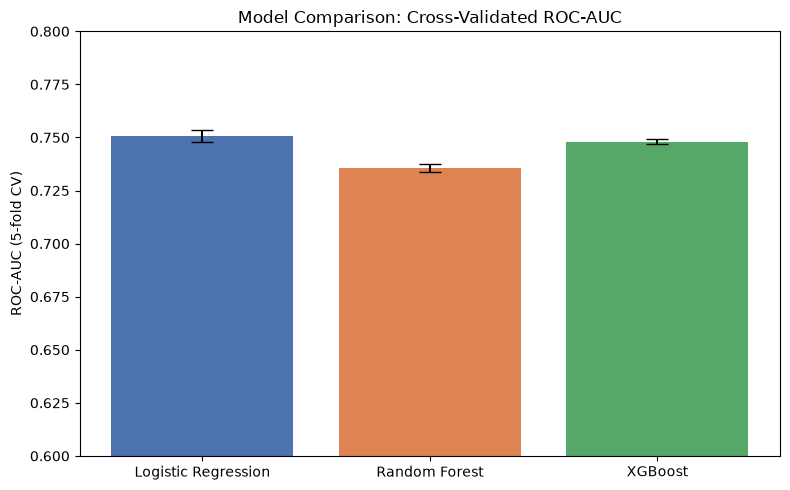

In [29]:
# Bar plot for Test ROC-AUC
fig, ax = plt.subplots(figsize=(8, 5))

means = comparison_df['CV Mean ROC-AUC']
stds = comparison_df['CV Std']
names = comparison_df['Model']

ax.bar(names, means, yerr=stds, capsize=8, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_ylabel('ROC-AUC (5-fold CV)')
ax.set_title('Model Comparison: Cross-Validated ROC-AUC')
ax.set_ylim(0.6, 0.8)

plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150)
plt.show()

In [30]:
# Feature importance for XGBoost model
import numpy as np

feature_names = X_encoded.columns
xgb_importances = xgb_model.feature_importances_

xgb_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_importances
}).sort_values('importance', ascending=False)

print(xgb_importance_df.head(15))

                                               feature  importance
28                                        EXT_SOURCE_2    0.028713
29                                        EXT_SOURCE_3    0.027218
133                         NAME_INCOME_TYPE_Pensioner    0.024237
138               NAME_EDUCATION_TYPE_Higher education    0.018869
120                                      CODE_GENDER_M    0.018305
122                                     FLAG_OWN_CAR_Y    0.014670
141  NAME_EDUCATION_TYPE_Secondary / secondary special    0.011830
119                 NAME_CONTRACT_TYPE_Revolving loans    0.011679
27                                        EXT_SOURCE_1    0.010948
79                                     FLAG_DOCUMENT_3    0.009144
115                              PREV_APP_REFUSAL_RATE    0.008960
137                           NAME_INCOME_TYPE_Working    0.008820
19                         REGION_RATING_CLIENT_W_CITY    0.008786
142                         NAME_FAMILY_STATUS_Married    0.00

In [31]:
# Feature importance plot for logistic regression model
lr_coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(lr_coef_df.head(15))

                                               feature  coefficient
4                                      AMT_GOODS_PRICE    -0.963333
2                                           AMT_CREDIT     0.912554
29                                        EXT_SOURCE_3    -0.438660
28                                        EXT_SOURCE_2    -0.383267
141  NAME_EDUCATION_TYPE_Secondary / secondary special     0.341998
59                                   BASEMENTAREA_MEDI     0.336861
31                                    BASEMENTAREA_AVG    -0.330100
41                                      LIVINGAREA_AVG     0.290401
69                                     LIVINGAREA_MEDI    -0.234903
68                               LIVINGAPARTMENTS_MEDI     0.227372
73                            OBS_30_CNT_SOCIAL_CIRCLE     0.217199
138               NAME_EDUCATION_TYPE_Higher education     0.212892
117                              PREV_APP_ANNUITY_MEAN    -0.211510
75                            OBS_60_CNT_SOCIAL_